# Uplift Modelling on the Hillstrom E-Mail Campaign

**Data.** The MineThatData e-mail challenge: 64,000 customers randomly assigned to one of three
arms: a women's merchandise e-mail, a men's merchandise e-mail, or no e-mail. This notebook uses
the **`Womens E-Mail` vs `No E-Mail`** comparison (42,693 customers, ~50/50), with a 25% test
split (10,674 customers).

Since assignment was randomized, treated and control customers are
exchangeable. That is what makes the *incremental* effect of the e-mail identifiable at all —
without randomization we could only measure who responds, not who responds *because* of the mail.

**Baseline effect.** Averaged over everyone:

| outcome | treated | control | incremental (ATE) |
|---|---|---|---|
| visit | 15.14% | 10.62% | **+4.52 pp** |
| conversion | 0.884% | 0.573% | **+0.311 pp** |
| spend | \$1.077 | \$0.653 | **+\$0.424 per e-mail** |

While emailing everyone works on average, this project seeks to answer: can we rank customers by how much the e-mail moves them, so the same lift can be bought with fewer sends?

Three uplift learners are compared across repeated train/test splits on two
outcomes (`visit`, `conversion`), then the winning ranking is translated into a top-N% targeting
policy with its incremental-conversion and cost implications.


In [18]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_prep import load_and_prepare
from src.t_learner import run_two_model
from src.uplift_trees import train_uplift_rf
from src.meta_learners import run_x_learner
from src.evaluation import qini_curve, sample_qini_curves, plot_qini_distribution
from src.stability import run_stability_check

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
plt.style.use("bmh")


## Re-fitting a specific run

The stability sweep returns one row per `(split_seed, model_seed, model)` combination but
does not keep the fitted models or their scores. `make_run_lookup` returns a function that rebuilds any single
run on demand from its two seeds. Because `load_and_prepare` and each learner are deterministic
given their seeds, the rebuilt run is identical to the one that produced the row. This is what
lets the Qini-curve plots later pick out the best / median / worst run from the results table and
re-draw exactly those.


In [20]:
def make_run_lookup(arm, outcome):

    def run_lookup(split_seed, model_seed, model_type):
        X_train, X_test, y_train, y_test, treatment_train, treatment_test = \
            load_and_prepare(treatment_arm=arm, random_state=split_seed)

        if model_type == "T-Learner":
            uplift_scores = run_two_model(
                X_train, treatment_train, y_train[outcome], X_test,
                random_state=model_seed, n_jobs=-1
            )
        elif model_type == "Uplift Trees":
            uplift_scores = train_uplift_rf(
                X_train, treatment_train, y_train[outcome], X_test,
                random_state=model_seed, max_depth=8, n_estimators=300,
                evaluationFunction="KL", n_jobs=-1
            )
        elif model_type == "X-Learner":
            uplift_scores = run_x_learner(
                X_train, treatment_train, y_train[outcome], X_test,
                random_state=model_seed, n_jobs=-1
            )

        return uplift_scores, treatment_test, y_test[outcome]

    return run_lookup


## Methodology

### Repeated Splits

Uplift is a difference of two noisy rates, so it is far noisier than ordinary response modeling, and on
a rare outcome like conversion, a single split can easily rank models by luck.

`run_stability_check` stabilizes two independent sources of noise:

- **`split_seed`** — which customers land in train vs test (sampling noise),
- **`model_seed`** — the learner's own randomness at fixed data (fit noise),

fitting every model on every combination in parallel and returning one row per run. With
15 splits × 2 model seeds that is **30 runs per model**.

### Three Learners

| learner | how it estimates uplift                                                                                                                                                                                                                       |
|---|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **T-Learner** | Two separate classifiers (one on treated, one on control); uplift = difference of their predicted probabilities. Simple, but each model is fit to the *level* of response, so small true differences can be swamped by each model's own error. |
| **Uplift Trees** | A random forest whose split criterion is the **KL divergence** between the treated and control response distributions — it splits directly on treatment-effect heterogeneity rather than on outcome purity.                                   |
| **X-Learner** | Two-stage: impute each customer's treatment effect using the other arm's model, then regress those imputed effects on features. More robust when arms are imbalanced or the outcome is rare.       |

### The Metric: Qini

Sort the test set by predicted uplift, descending. Walking down that list, the **Qini curve**
plots the cumulative *incremental* conversions (treated conversions minus control conversions,
rescaled for the treated/control ratio at each depth) against the fraction of the population
contacted. The straight diagonal is what random targeting would achieve. The Qini coefficient is the area between the curve and that
diagonal: how much better than random the ranking is.

`qini_coefficient` supports three scalings (see `src/evaluation.py`):

- `None` — raw area, in incremental-event units. Scales with sample size and base rate, so it is
  **not** comparable across outcomes.
- `"gain"` — divided by the campaign's total incremental gain. Unitless, roughly $[-0.5, 0.5]$;
  reads as "how front-loaded the gain is".
- `"perfect"` — divided by the best curve achievable on this data, given by an oracle ranking that
  can see the realised outcome. Unitless, $\le 1$.

Everything below uses **`normalize="perfect"`**, so a number reads directly as the fraction of
attainable uplift the model captured, and `visit` and `conversion` results can be directly compared. The oracle is a ceiling no feature-based model can reach — it uses $y$ — so absolute
values are expected to be small; what matters is the comparison between models.

---

## Outcome 1 — Visit

`visit` fires for ~13% of customers, so each split contains well over a thousand events. This is
the *easy* outcome: enough signal that model differences, if any exist, should be visible.


In [21]:
df_visit = run_stability_check(
    n_splits=15,
    n_model_seeds=2,
    models=("T-Learner", "Uplift Trees", "X-Learner"),
    arm="Womens E-Mail",
    outcome="visit",
    max_workers=12,
    normalize="perfect"
)

print(df_visit.groupby("model")["qini_coefficient"].agg(["mean", "std", "count"]))

                  mean       std  count
model                                  
T-Learner     0.056743  0.015797     30
Uplift Trees  0.057440  0.013526     30
X-Learner     0.058747  0.016730     30



### Reading the visit results

| model | mean | std | n |
|---|---|---|---|
| T-Learner | 0.0567 | 0.0158 | 30 |
| Uplift Trees | 0.0574 | 0.0135 | 30 |
| X-Learner | 0.0587 | 0.0167 | 30 |

**All three models capture roughly 6% of the attainable uplift on `visit`.** The spread between
model means (0.0567 → 0.0587, a gap of 0.002) is about an eighth of any single model's standard
deviation (~0.015). In other words the between-model difference is far smaller than the
run-to-run noise within each model: **on `visit`, no learner is meaningfully better than the
others.**

Positive coefficients across all 30 runs of every model do confirm the rankings beat random
targeting, just not differently from each other.


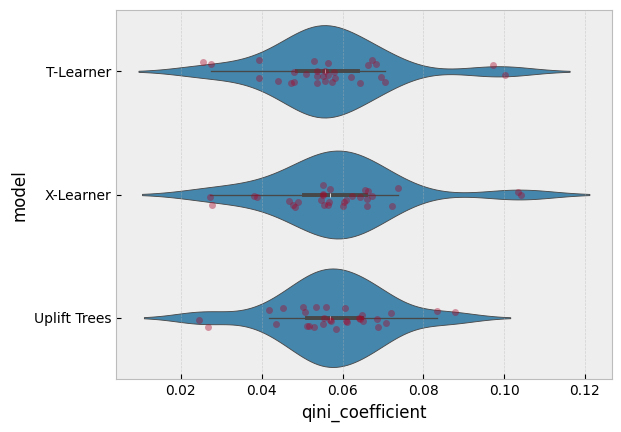

In [22]:
ax = plot_qini_distribution(df_visit, metric="qini_coefficient")
plt.show()


The violin plot shows the three distributions sitting on top of one another. Every distribution sits entirely above zero, meaning the rankings are better than
random even though they are indistinguishable from each other.


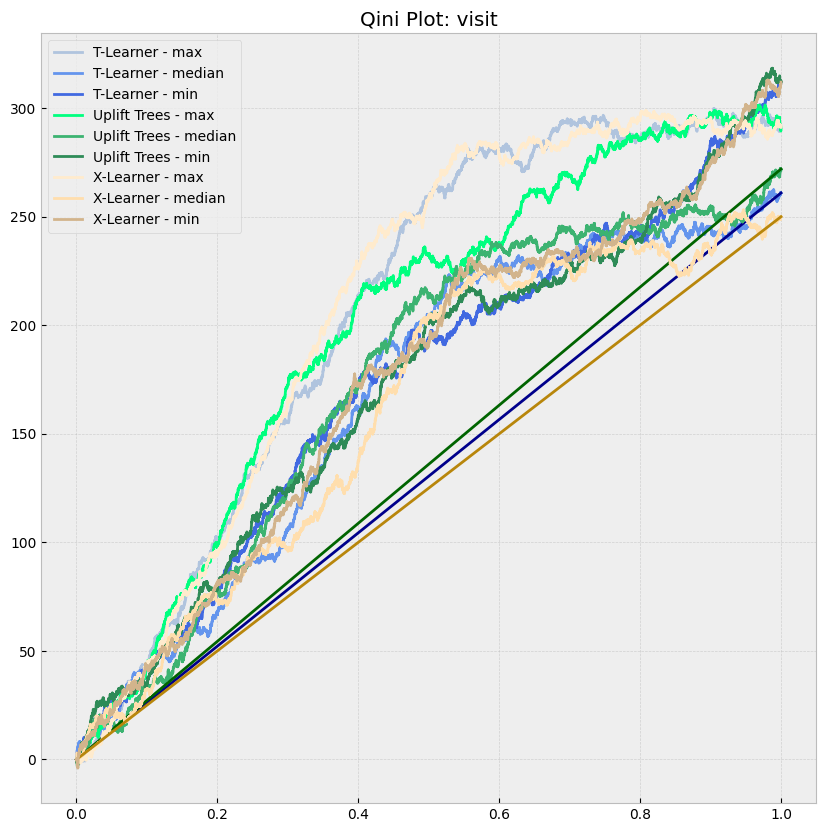

In [23]:
run_lookup = make_run_lookup(arm="Womens E-Mail", outcome="visit")

fig, ax = plt.subplots(figsize=(10, 10))

for model, colors in {
                      "T-Learner": [["lightsteelblue", "cornflowerblue", "royalblue"], "darkblue"],
                      "Uplift Trees": [["springgreen", "mediumseagreen", "seagreen"], "darkgreen"],
                      "X-Learner": [["blanchedalmond", "navajowhite", "tan"], "darkgoldenrod"]
}.items():
    sample_qini_curves(df_visit, run_lookup, model, curve_colors=colors[0], diagonal_color=colors[1], ax=ax)

plt.show()


Each model contributes three curves — its **best**, **median** and **worst** run out of 30 — with
the diagonal drawn once per model at its median run. The gap between a model's best and worst
curve is the point of the plot: the same learner, same data source, different split, produces
visibly different-looking targeting performance. Reading horizontally instead of
vertically: at any depth on the x-axis, the vertical distance from the diagonal is the extra
incremental visits that ranking buys over mailing a random sample of the same size.

---

## Outcome 2 — Conversion

`conversion` is the more important outcome: which customers actually purchase. ~0.57% of control customers and ~0.88% of mailed
customers convert. That means in our test set, there are only about 70 conversions in total, split
across two arms. Every Qini number below is built from that handful of events, which is the single
most important thing to keep in mind when reading the spread.


In [24]:
df_conversion = run_stability_check(
    n_splits=15,
    n_model_seeds=2,
    models=("T-Learner", "Uplift Trees", "X-Learner"),
    arm="Womens E-Mail",
    outcome="conversion",
    max_workers=12,
    normalize="perfect"
)

pivoted = df_conversion.pivot_table(
        index=["split_seed", "model_seed"], columns="model", values="qini_coefficient"
    )
win_rate_vs_t_learner = (pivoted["X-Learner"] > pivoted["T-Learner"]).mean()
win_rate_vs_uplift_trees = (pivoted["X-Learner"] > pivoted["Uplift Trees"]).mean()

print(df_conversion.groupby("model")["qini_coefficient"].agg(["mean", "std", "count"]))
print(f"\nX-Learner beat T-Learner {win_rate_vs_t_learner*100}% of runs")
print(f"X-Learner beat Uplift Trees {win_rate_vs_uplift_trees*100}% of runs")


                  mean       std  count
model                                  
T-Learner     0.039493  0.047739     30
Uplift Trees  0.051710  0.041036     30
X-Learner     0.083648  0.049876     30

X-Learner beat T-Learner 93.33333333333333% of runs
X-Learner beat Uplift Trees 83.33333333333334% of runs



### Reading the conversion results

| model | mean | std | n |
|---|---|---|---|
| T-Learner | 0.0395 | 0.0477 | 30 |
| Uplift Trees | 0.0517 | 0.0410 | 30 |
| **X-Learner** | **0.0836** | 0.0499 | 30 |

**The X-Learner more than doubles the T-Learner on the mean** (0.084 vs 0.039) and leads Uplift
Trees by ~60% (0.084 vs 0.052) — a much larger gap than anything seen on `visit`. This makes
sense: the X-Learner's imputation stage is specifically designed for rare outcomes and
noisy arm-level estimates, which is precisely the ~0.7%-event regime here.

**But the standard deviation is ~0.041–0.050 for every model** — roughly three times the `visit`
noise, and about the size of the gap itself. The X-Learner's advantage is therefore on the order of
**one standard deviation**, from 30 runs. That is *suggestive, not conclusive.* With 15 splits the
standard error on each mean is ~0.013, so the gaps (0.044 vs T-Learner, 0.032 vs Uplift Trees) are
two to three standard errors wide — but the 30 runs are not independent (each split seed is reused
across models), so the naive test overstates the evidence.

Doing a paired comparison as a follow-up:

- X-Learner win rate vs Uplift Trees: `83.3%` (25 of 30 runs)
- X-Learner win rate vs T-Learner: `93.3%` (28 of 30 runs)
- Runs (`n_splits` × `n_model_seeds`) used for the win rate: `30` (15 × 2)

Winning 25 and 28 of 30 paired runs is much stronger evidence than the overlapping distributions
suggest on their own: the shared split noise moves all three models together, so once it is
differenced out the X-Learner's edge is consistent rather than marginal.


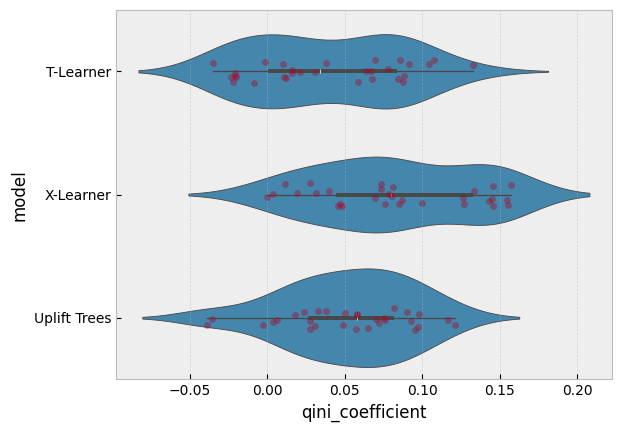

In [25]:
ax = plot_qini_distribution(df_conversion, metric="qini_coefficient")
plt.show()


Compared to `visit`, two things change: every distribution is much wider (rare
outcome, fewer events per split), and the X-Learner's mass is visibly shifted right rather than
merely overlapping. The tails still cross — some X-Learner runs land below some Uplift Trees runs
— so this is a distributional edge, not a guarantee on any single split. Any run near or below
zero is a split where the ranking did no better than random.


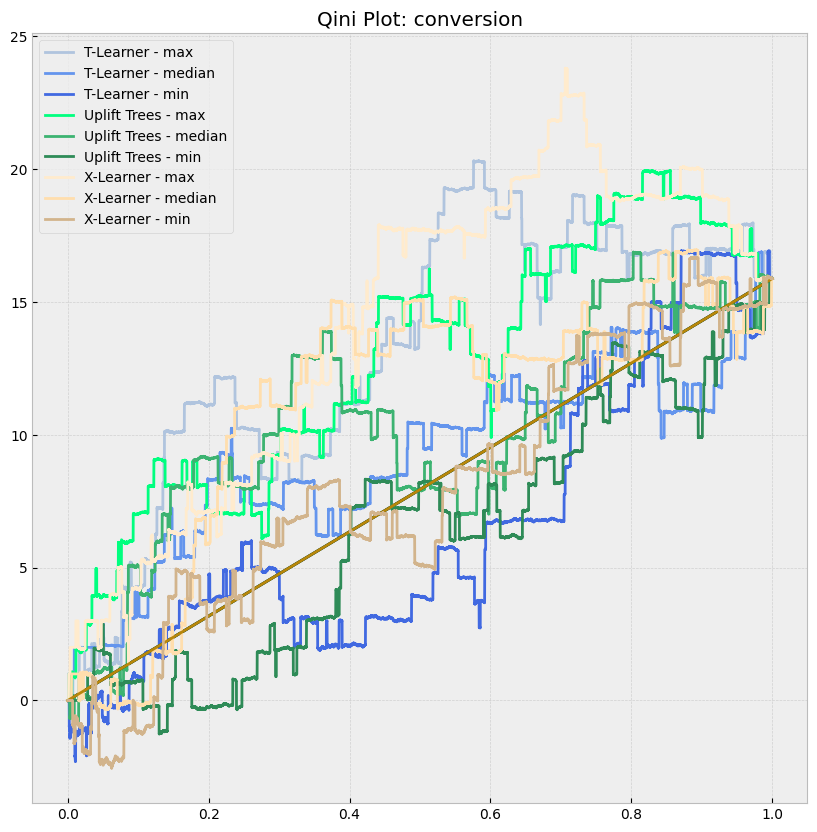

In [26]:
run_lookup = make_run_lookup(arm="Womens E-Mail", outcome="conversion")

fig, ax = plt.subplots(figsize=(10, 10))

for model, colors in {
                      "T-Learner": [["lightsteelblue", "cornflowerblue", "royalblue"], "darkblue"],
                      "Uplift Trees": [["springgreen", "mediumseagreen", "seagreen"], "darkgreen"],
                      "X-Learner": [["blanchedalmond", "navajowhite", "tan"], "darkgoldenrod"]
}.items():
    sample_qini_curves(df_conversion, run_lookup, model, curve_colors=colors[0], diagonal_color=colors[1], ax=ax)

plt.show()


The same best / median / worst, now on conversions. Two features are worth noting against
the `visit` version:

- The curves are jagged due to the sparsity of the events.
- There is a larger difference between the best and worst runs, and worst-case curves can dip below their
  diagonal at some depths.


---

## Business translation: a top-N% targeting policy

The business policy made possible by this analysis is as follows:

> Score the mailable base with the uplift model, sort descending, and mail the **top N%**. Suppress
> the rest.

Two things follow from framing it this way.

**Model choice is a ranking decision, not an accuracy decision.** Nothing in the policy uses the
predicted uplift *value*, only the order. A model with badly calibrated magnitudes but the right
ordering is worth more here than a well-calibrated one that sorts poorly. That is why the whole
notebook is scored on Qini rather than on error.

**The Qini curve already is the policy simulator.** Its height at depth $p$ is precisely "the
incremental conversions we would have captured by mailing the top $p$" measured on a held-out
randomized sample, so it is a genuine counterfactual and not a fitted projection.

The cell below reads those depths off the curve for the best conversion model, using the
median of its 30 runs.


In [27]:
POLICY_MODEL = "X-Learner"
DEPTHS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]

model_df = df_conversion[df_conversion["model"] == POLICY_MODEL]
median_index = (model_df["qini_coefficient"] - model_df["qini_coefficient"].median()).abs().idxmin()
median_run = model_df.loc[median_index]

run_lookup = make_run_lookup(arm="Womens E-Mail", outcome="conversion")
uplift_scores, treatment, outcome = run_lookup(
    median_run["split_seed"], median_run["model_seed"], model_type=POLICY_MODEL
)

pct_targeted, cumulative_gain, _ = qini_curve(uplift_scores, treatment, outcome)
n_customers = len(treatment)
total_gain = cumulative_gain[-1]          # G(1): incremental conversions from mailing everyone

policy = pd.DataFrame({"pct_contacted": DEPTHS})
policy["contacts"] = (policy["pct_contacted"] * n_customers).round().astype(int)
policy["contacts_saved"] = n_customers - policy["contacts"]
policy["incremental_conversions"] = np.interp(policy["pct_contacted"], pct_targeted, cumulative_gain)
policy["pct_of_total_gain"] = policy["incremental_conversions"] / total_gain
policy["conversions_given_up"] = total_gain - policy["incremental_conversions"]
# random targeting captures exactly `pct_contacted` of the gain, so this is the model's edge
policy["lift_vs_random"] = policy["pct_of_total_gain"] / policy["pct_contacted"]
# targeting at depth p beats mailing everyone when cost-per-contact / margin-per-conversion
# exceeds this threshold
policy["breakeven_c_over_m"] = policy["conversions_given_up"] / (
    (1 - policy["pct_contacted"]) * n_customers
)

print(f"policy run: {POLICY_MODEL}, split_seed={median_run['split_seed']}, "
      f"model_seed={median_run['model_seed']}, qini={median_run['qini_coefficient']:.4f}")
print(f"test set: {n_customers} customers, {total_gain:.1f} incremental conversions if all mailed")
policy.round(4)

policy run: X-Learner, split_seed=11, model_seed=0, qini=0.0807
test set: 10674 customers, 15.9 incremental conversions if all mailed


,pct_contacted,contacts,contacts_saved,incremental_conversions,pct_of_total_gain,conversions_given_up,lift_vs_random,breakeven_c_over_m
0,0.1,1067,9607,-0.1481,-0.0093,16.0317,-0.0932,0.0017
1,0.2,2135,8539,5.8996,0.3714,9.9840,1.8571,0.0012
2,0.3,3202,7472,11.0904,0.6982,4.7932,2.3274,0.0006
3,0.4,4270,6404,14.0672,0.8856,1.8164,2.2141,0.0003
4,0.5,5337,5337,15.0851,0.9497,0.7985,1.8995,0.0001
5,0.7,7472,3202,12.8636,0.8099,3.0200,1.1570,0.0009
6,1.0,10674,0,15.8836,1.0000,0.0000,1.0000,NaN



### Reading the policy table

- Total incremental conversions if we mail **everyone** in the test set: `15.88`
- Contacting the **top `50`%** captures **`95.0`%** of those incremental conversions,
  i.e. `15.09` of `15.88` conversions, while sending `5337` fewer e-mails.
- `lift_vs_random` at that depth: `1.8995`× — random targeting at the same depth would capture
  exactly the depth itself (30% of people → 30% of the gain), so anything above 1.0 is the value
  the model adds.

It's worth noting that the top decile shows
*negative* incremental conversions (-0.15, `lift_vs_random` of -0.09), and the curve is
non-monotonic (it peaks at 15.09 at 50% depth, falls to 12.86 at 70%, then returns to 15.88).
However, this is just noise. The test set holds ~47 treated and ~31 control conversions, so
the top decile contains approximately 8 events across both arms; Poisson noise on their difference is
~±3 conversions. Both the negative decile and the 2.2-conversion dip are under one standard
deviation of that. They are just a consequence of noisy signal.
